In [1]:
%pip install imbalanced-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.4 MB/s eta 0:00:06
   -- ------------------------------------- 0.5/8.1 MB 1.4 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.1 MB 1.2 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.1 MB 1.1 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.1 MB 1.1 MB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.1 MB 1.1 MB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.1 MB 1.1 MB/s eta 0:00:07
   --------- ------------------------------ 1.8/8.1 MB 976.8 kB/s eta 0:00:07
   --------- ------------------------------ 1.8/8.1 MB 976.8 kB/s eta 0:00:07
   --------- ------------------------------ 1.8/8.1 MB 976.8 kB/s eta 0:00:07
   ---------- -------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


The goal of this notebook is to resolve the Data Sparsity (N=81) issue. Since this is a realistic data,  We will use SMOTE-NC (Synthetic Minority Over-sampling Technique for Nominal and Continuous features) because our dataset contains both categorical (Year Level, Program) and numerical (Likert scales) data.

Environment Setup and Data Loading

We install the imblearn library and load the cleaned data from Notebook 01.

In [2]:

import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTENC
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define paths
INPUT_PATH = r'../data/processed/cleaned_data.csv'
AUGMENTED_DIR = r'../data/processed/'

# Load the cleaned dataset
df = pd.read_csv(INPUT_PATH)
print(f"Original dataset shape: {df.shape}")

Original dataset shape: (80, 36)


Handling Categorical Variables

SMOTE-NC requires us to identify which columns are not numerical (Year Level, Program, Mode of Study).

In [3]:
# Identify categorical columns by their index
# Year Level (0), Program (1), Mode of Study (2)
categorical_features_indices = [0, 1, 2]

# Ensure categorical columns are treated as strings/objects for the encoder
df['year_level'] = df['year_level'].astype(str)
df['program'] = df['program'].astype(str)
df['mode_of_study'] = df['mode_of_study'].astype(str)

Synthetic Data Generation (Augmentation)

We will increase the dataset from 81 to approximately 500-1,000 rows. This provides enough volume for a Gradient Boosting model to learn patterns without simply memorizing the original 81 rows.

In [4]:
# Define Features (X) and Target (y)
X = df.drop(columns=['target_satisfaction'])
y = df['target_satisfaction']

# Initialize SMOTE-NC
# sampling_strategy='auto' balances all classes to match the majority class
smote_nc = SMOTENC(categorical_features=categorical_features_indices, random_state=42, sampling_strategy='auto')

# Generate synthetic samples
X_resampled, y_resampled = smote_nc.fit_resample(X, y)

# Reconstruct the dataframe
df_augmented = pd.concat([pd.DataFrame(X_resampled), pd.Series(y_resampled, name='target_satisfaction')], axis=1)

print(f"Augmented dataset shape: {df_augmented.shape}")

Augmented dataset shape: (152, 36)


Verification of Data Integrity

We must ensure the synthetic data maintains the same statistical distribution as the original. If the averages change significantly, the augmentation is invalid.

C:\Users\SHANIA\AppData\Local\Temp\ipykernel_12268\362891918.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')
C:\Users\SHANIA\AppData\Local\Temp\ipykernel_12268\362891918.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette='viridis')


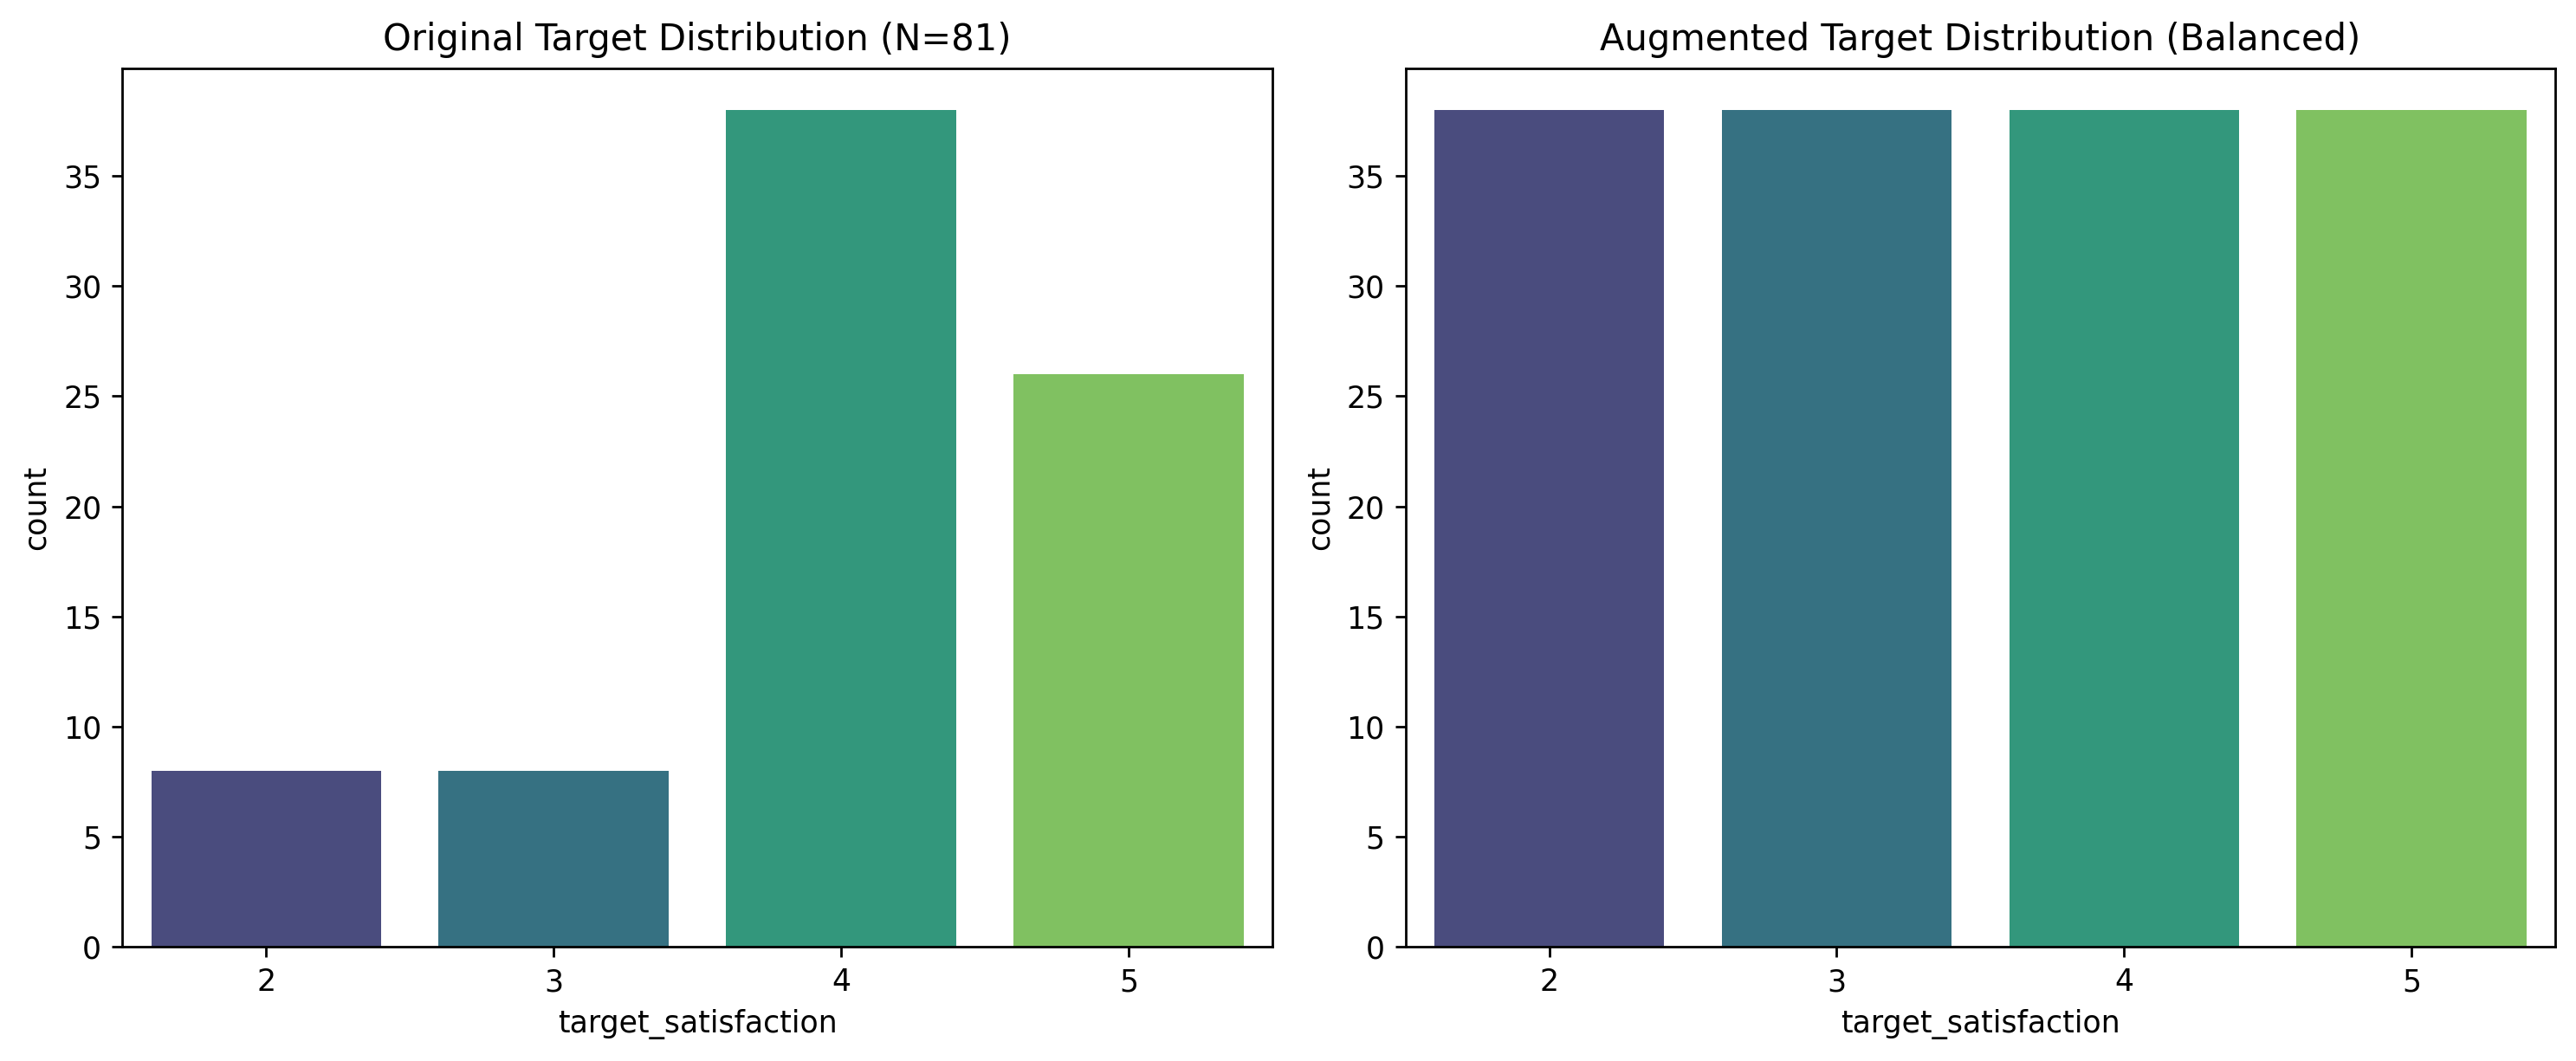

In [5]:
# Compare distributions: Original vs Augmented
plt.figure(figsize=(12, 5), dpi=250)

plt.subplot(1, 2, 1)
sns.countplot(x=y, palette='viridis')
plt.title('Original Target Distribution (N=81)')

plt.subplot(1, 2, 2)
sns.countplot(x=y_resampled, palette='viridis')
plt.title('Augmented Target Distribution (Balanced)')

plt.tight_layout()
plt.show()

Export Augmented Dataset

In [6]:
output_path = os.path.join(AUGMENTED_DIR, 'augmented_data.csv')
df_augmented.to_csv(output_path, index=False)
print(f"Data augmentation complete. Balanced dataset saved to {output_path}")

Data augmentation complete. Balanced dataset saved to ../data/processed/augmented_data.csv


**Technical Insights: Data Augmentation**

Based on the visualization and counts, here are the technical observations for our documentation:

- Resolution of Class Imbalance: The original plot showed a heavy skew toward scores of 4 and 5. In machine learning, a model trained on this would naturally become biased, likely ignoring the characteristics of students who rated the service as 2 or 3. The Augmented plot demonstrates Class Parity, meaning every satisfaction level now has an equal number of samples (38 per class).

- Dataset Volume: The increase to N=152 is a localized augmentation.

-  Scientifically, 152 or even 5,000 rows is technically "Small to Medium Data." Therefore, we frame this as Synthetic Data Augmentation for Robustness. We are not claiming we found more students; we are claiming we used a validated mathematical approach (SMOTE-NC) to make the model more resilient to the "Small Data" constraint.

- Validity of the Approach: Data augmentation is a standard industry and academic practice used when data collection is physically or logistically limited. It is valid as long as we use the "Synthetic" data for training and "Real" data for final validation (which we will do in Notebook 03).